In [66]:
from pathlib import Path
import numpy as np
import nibabel as nib
import pandas as pd
from scipy import stats
import os
import csv
import re
import matplotlib.pyplot as plt

In [67]:
# Checks the shape and affine of the files and make sures that the files have the same shape and affine

def check_shape_and_affine(diff_image, seg_nuclei_image, seg_fsv_image):

    """
    Compares diff_image, seg_nuclei_image and seg_fsv_image to each other. Checks the shape and affines, and if they are not the same, align the affine of seg_image to diff_image.
    If there is a shape mismatch --> raise ValueError
    If there is an affine mismatch --> align affine such that seg_nuclei_image and seg_fsv_image have the same affine as diff_image
    
    Input:
    - diff_image: nib.load(str(diff_path))
    - seg_nuclei_image: nib.load(str(seg_nuclei_path))
    - seg_fsv_image: nib.load(str(seg_fsv_path))

    Vil kanskje endre til å ta inn paths?

    Output:
    - Corrected seg_nuclei_image and seg_fsv_image

    Vil kanskje endre til path, eventuelt legge til paths?
    """

    same_shape_nuclei = (diff_image.shape == seg_nuclei_image.shape)
    same_affine_nuclei = np.allclose(diff_image.affine, seg_nuclei_image.affine)
    same_shape_fsv = (diff_image.shape == seg_fsv_image.shape)
    same_affine_fsv = np.allclose(diff_image.affine, seg_fsv_image.affine)
    
    if not ((same_shape_nuclei) and (same_shape_fsv)):
        raise ValueError(f"Shape mismatch")

    if not (same_affine_nuclei):
        print(f"Affine mismatch (nuclei) --> reorienting")

        # Given this affine: what axis corresponds to LR, AP, IS (ornt representation)
        seg_ornt = nib.orientations.io_orientation(seg_nuclei_image.affine)

        # Given this affine: give me the coordinate system and the corresponding ornt representation
        diff_ax = nib.orientations.aff2axcodes(diff_image.affine) # For instance LAS, RAS, etc...
        target_ornt = nib.orientations.axcodes2ornt(diff_ax)

        # A new ornt that tells you how to re-order/flip
        transform = nib.orientations.ornt_transform(seg_ornt, target_ornt)

        # Apply transform to change voxel indexing
        seg_data = seg_nuclei_image.get_fdata()
        seg_data_reoriented = nib.orientations.apply_orientation(seg_data, transform)

        # Maps new voxel indexes to same world coordinates
        new_affine = seg_nuclei_image.affine @ nib.orientations.inv_ornt_aff(transform, seg_nuclei_image.shape)

        seg_nuclei_image = nib.Nifti1Image(seg_data_reoriented, new_affine, seg_nuclei_image.header)
        #nib.save(seg_nuclei_image, "seg_nuclei_image_reoriented.nii.gz")

        same_shape = (diff_image.shape == seg_nuclei_image.shape)
        same_affine = np.allclose(diff_image.affine, seg_nuclei_image.affine)

        if not ((same_shape) and (same_affine)):
              raise ValueError("Still mismatch in affine (or shape) for nuclei")

    if not (same_affine_fsv):
        print(f"Affine mismatch (fsv) --> reorienting")

        # Given this affine: what axis corresponds to LR, AP, IS (ornt representation)
        seg_ornt = nib.orientations.io_orientation(seg_fsv_image.affine)

        # Given this affine: give me the coordinate system and the corresponding ornt representation
        diff_ax = nib.orientations.aff2axcodes(diff_image.affine)
        target_ornt = nib.orientations.axcodes2ornt(diff_ax)

        # A new ornt that tells you how to re-order/flip
        transform = nib.orientations.ornt_transform(seg_ornt, target_ornt)

        # Apply transform to change voxel indexing
        seg_data = seg_fsv_image.get_fdata()
        seg_data_reoriented = nib.orientations.apply_orientation(seg_data, transform)

        # Maps new voxel indexes to same world coordinates
        new_affine = seg_fsv_image.affine @ nib.orientations.inv_ornt_aff(transform, seg_fsv_image.shape)

        seg_fsv_image = nib.Nifti1Image(seg_data_reoriented, new_affine, seg_fsv_image.header)
        #nib.save(seg_fsv_image, "seg_fsv_image_reoriented.nii.gz")

        same_shape = (diff_image.shape == seg_fsv_image.shape)
        same_affine = np.allclose(diff_image.affine, seg_fsv_image.affine)

        if not ((same_shape) and (same_affine)):
              raise ValueError("Still mismatch in affine (or shape) for fsv")
        
    return seg_nuclei_image, seg_fsv_image

In [69]:
# Extract certain statistical metrics from the different segments in the segment map

def extract_statistical_metrics_from_segments(diff_image, seg_nuclei_image, seg_fsv_image, subj_id, param_name):

    """
    Extracts statistical metrics from the different segments in seg_nuclei_image and seg_fsv_image on diff_image

    Input:
    - diff_image: nib.load(str(diff_path))
    - seg_nuclei_image: nib.load(str(seg_nuclei_path))
    - seg_fsv_image: nib.load(str(seg_fsv_path))
    - subj_id: subject ID [string/int/float]
    - param_name: name of parameter (FA, MD,...) [string]

    Output:
    - List of different statistical metrics as well as information about subject, parameter and segment
    """

    # Convert to arrays
    diff_data = diff_image.get_fdata()
    seg_nuclei_data = np.rint(seg_nuclei_image.get_fdata()).astype(np.int32)
    seg_fsv_data = np.rint(seg_fsv_image.get_fdata()).astype(np.int32)

    labels_nuclei = np.unique(seg_nuclei_data)
    labels_fsv = np.unique(seg_fsv_data)

    rows_local = []

    # Iterate through the segments
    for el in labels_nuclei:
        mask = (seg_nuclei_data == el)
        diff_values = diff_data[mask]
            
        mean = np.mean(diff_values)
        std = np.std(diff_values)
        median = np.median(diff_values)
        max = np.max(diff_values)
        min = np.min(diff_values)
        five_percentile = np.percentile(diff_values, 5)
        skewness = stats.skew(diff_values)
        kurtosis = stats.kurtosis(diff_values)

        rows_local.append({
            "Subject": subj_id,
            "Parameter": param_name,
            "Segment": el,
            "Segmentation tool": "nuclei",
            "Mean": mean,
            "Standard deviation": std,
            "Median": median,
            "Maximum value": max,
            "Minimum value": min,
            "5th percentile": five_percentile,
            "Skewness": skewness,
            "Kurtosis": kurtosis
        })
    
    for el in labels_fsv:
        mask = (seg_fsv_data == el)
        diff_values = diff_data[mask]

        mean = np.mean(diff_values)
        std = np.std(diff_values)
        median = np.median(diff_values)
        max = np.max(diff_values)
        min = np.min(diff_values)
        five_percentile = np.percentile(diff_values, 5)
        skewness = stats.skew(diff_values)
        kurtosis = stats.kurtosis(diff_values)

        rows_local.append({
            "Subject": subj_id,
            "Parameter": param_name,
            "Segment": el,
            "Segmentation tool": "fsv",
            "Mean": mean,
            "Standard deviation": std,
            "Median": median,
            "Maximum value": max,
            "Minimum value": min,
            "5th percentile": five_percentile,
            "Skewness": skewness,
            "Kurtosis": kurtosis
        })

    return rows_local

In [70]:
# Extracts statistical metrics from the different segments in the segment map for every diffusion file and every subject

def extract_diffusion_stats_from_segments(path_to_folder, segment_Nuclei_suffix, segment_FSV_suffix):

    """"
    Extracts statistical metrics from the different segments in the segment map for every diffusion file and every subject in the path "path_to_folder"
    
    Input:
    - path_to_folder: the path to the folder [string]
    - segment_Nuclei_suffix: suffix of filename of Nuclei segment [string]
    - segment_FSV_suffix: suffix of filename of FSV segment [string]

    Output:
    - csv with all the information about subject, parameter, segment, statistical metrics etc.
    """

    parent_dir = Path(path_to_folder)
    seg_nuclei_suffix = segment_Nuclei_suffix
    seg_fsv_suffix = segment_FSV_suffix

    # Iterate through the subject folders
    for subj_dir in sorted ([p for p in parent_dir.iterdir() if p.is_dir()]): # Iterate through all folders in parent_dir, sorted alphabetically
        subj_id = subj_dir.name
        seg_nuclei_path = subj_dir / f"{subj_id}{seg_nuclei_suffix}"
        seg_fsv_path = subj_dir / f"{subj_id}{seg_fsv_suffix}"
        
        orig_seg_nuclei_image = nib.load(str(seg_nuclei_path))
        orig_seg_fsv_image = nib.load(str(seg_fsv_path))

        rows = []

        diff_files = sorted(f for f in subj_dir.glob("dti_epic_denoised_eddy_dti_*.nii.gz") if not any(x in f.name for x in ["tensor", "V1", "V2", "V3"]))

        # Iterate through the diffusion files
        for diff_path in diff_files:
            param_name = diff_path.name.replace(".nii.gz", "").split("_")[-1]
            diff_image = nib.load(str(diff_path))
            seg_nuclei_image = orig_seg_nuclei_image
            seg_fsv_image = orig_seg_fsv_image

            seg_nuclei_image_correct, seg_fsv_image_correct = check_shape_and_affine(diff_image, seg_nuclei_image, seg_fsv_image)

            rows_local = extract_statistical_metrics_from_segments(diff_image, seg_nuclei_image_correct, seg_fsv_image_correct, subj_id, param_name)

            rows.extend(rows_local)
        
        df = pd.DataFrame(rows)
        #print(df)
        df.to_csv(subj_dir / "Statistical metrics for different diffusion parameters_function", index = False)

             

In [10]:
extract_diffusion_stats_from_segments("/home/thientn/MASTEROPPGAVE/IMPARK/", "_nuclei_dwi-space.nii.gz", "_fsv_dwi-space.nii.gz")

Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (fsv) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorienting
Affine mismatch (nuclei) --> reorient

In [72]:
# Make SNR-masks

def make_SNR_mask(raw_file_path_name, threshold_number, volume_indices=None, volume_label=""):

    """
    Make SNR-masks based on a threshold number and specific volumes
    
    Input:
    - raw_file_path_name: file path to raw data [string]
    - threshold_number: threshold value to keep voxel [int/float]
    - volume_indices: list of volumes to use for mean. If None --> uses all volumes
    - volume_label: label for filename [string]

    Output:
    - SNR-mask path
    """
    
    raw_file_path = raw_file_path_name
    threshold = threshold_number

    raw_image = nib.load(raw_file_path)
    raw_data = raw_image.get_fdata()

    if raw_data.ndim != 4:
        raise ValueError("Input image must be 4D (x, y, z, volumes)")
    
    n_volumes = raw_data.shape[3]

    if volume_indices is None:
        volume_indices = np.arange(n_volumes)
    
    raw_data_subset = raw_data[:, :, :, volume_indices]

    # Mean signal across volumes
    mean_signal = np.mean(raw_data_subset, axis = 3)     # 3D-image

    # Creating SNR-mask
    SNR_mask = mean_signal >= threshold                  # 3D-image with True/False

    raw_file_dir = os.path.dirname(raw_file_path)
    threshold_string = str(threshold).replace(".", "p")

    SNR_mask_filename = f"SNR_mask_{volume_label}_threshold_{threshold_string}.nii.gz"
    mean_filename = f"mean_signal_{volume_label}_threshold_{threshold_string}.nii.gz"

    SNR_mask_path = os.path.join(raw_file_dir, SNR_mask_filename)
    mean_path = os.path.join(raw_file_dir, mean_filename)

    SNR_mask_image = nib.Nifti1Image(SNR_mask.astype(np.uint8), raw_image.affine, raw_image.header)
    mean_image = nib.Nifti1Image(mean_signal.astype(np.float32), raw_image.affine, raw_image.header)
    nib.save(SNR_mask_image, SNR_mask_path)
    nib.save(mean_image, mean_path)

    return SNR_mask_path

In [244]:
b0 = np.asarray([0, 61, 62, 63, 64, 65])
b1000 = np.arange(1, 31)
b2000 = np.arange(31, 61)
all = np.arange(0, 66)

# b0 thresholds: 200, 350, 500, 650, 800
# b1000 thresholds: 60, 80, 100, 120, 140
# b2000 thresholds: 40, 60, 80, 100, 120
# all thresholds: 40, 60, 80, 100, 120

SNR_path_b0_thres70 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 70, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres75 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 75, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres80 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 80, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres90 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 90, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres100 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 100, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres120 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 120, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres150 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 150, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres200 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 200, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres350 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 350, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres500 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 500, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres650 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 650, volume_indices=b0, volume_label="b0")
SNR_path_b0_thres800 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 800, volume_indices=b0, volume_label="b0")

SNR_path_b1000_thres50 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 50, volume_indices=b1000, volume_label="b1000")
SNR_path_b1000_thres60 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 60, volume_indices=b1000, volume_label="b1000")
SNR_path_b1000_thres70 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 70, volume_indices=b1000, volume_label="b1000")
SNR_path_b1000_thres80 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 80, volume_indices=b1000, volume_label="b1000")
SNR_path_b1000_thres100 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 100, volume_indices=b1000, volume_label="b1000")
SNR_path_b1000_thres120 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 120, volume_indices=b1000, volume_label="b1000")
SNR_path_b1000_thres140 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 140, volume_indices=b1000, volume_label="b1000")

SNR_path_b2000_thres40 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 40, volume_indices=b2000, volume_label="b2000")
SNR_path_b2000_thres60 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 60, volume_indices=b2000, volume_label="b2000")
SNR_path_b2000_thres80 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 80, volume_indices=b2000, volume_label="b2000")
SNR_path_b2000_thres100 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 100, volume_indices=b2000, volume_label="b2000")
SNR_path_b2000_thres120 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 120, volume_indices=b2000, volume_label="b2000")

SNR_path_all_thres40 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 40, volume_indices=all, volume_label="all")
SNR_path_all_thres45 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 45, volume_indices=all, volume_label="all")
SNR_path_all_thres50 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 50, volume_indices=all, volume_label="all")
SNR_path_all_thres55 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 55, volume_indices=all, volume_label="all")
SNR_path_all_thres60 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 60, volume_indices=all, volume_label="all")
SNR_path_all_thres80 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 80, volume_indices=all, volume_label="all")
SNR_path_all_thres100 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 100, volume_indices=all, volume_label="all")
SNR_path_all_thres120 = make_SNR_mask("/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy.nii.gz", 120, volume_indices=all, volume_label="all")


In [73]:
# Make mask that is the union between the segment map and the SNR-mask

def make_seg_union_SNR_mask(seg_nuclei_path_name, seg_FSV_path_name, SNR_mask_path_name, label):
    """
    Make a mask that is the union between the segment maps (nuclei and FSV) and the SNR-mask
    
    Input:
    - seg_nuclei_path_name: path to nuclei segmentation file [string]
    - seg_FSV_path_name: path to FSV segmentation file [string]
    - SNR_mask_path_name: path to SNR mask [string]
    - label: 

    Output:
    - Paths to the nuclei union SNR-mask, and the fsv union SNR-mask
    - Corrected nuclei and fsv segment maps (correct shape and affine)
    """

    out_dir = os.path.dirname(SNR_mask_path_name)

    SNR_image = nib.load(SNR_mask_path_name)
    seg_nuclei_image = nib.load(seg_nuclei_path_name)
    seg_fsv_image = nib.load(seg_FSV_path_name)
    
    seg_nuclei_image_correct, seg_fsv_image_correct = check_shape_and_affine(SNR_image, seg_nuclei_image, seg_fsv_image)

    SNR = np.asanyarray(SNR_image.dataobj)
    nuclei = np.asanyarray(seg_nuclei_image_correct.dataobj)
    FSV = np.asanyarray(seg_fsv_image_correct.dataobj)

    SNR_bool = SNR > 0.5          # 3D True/False
    nuclei_all_seg = nuclei > 0   # 3D True/False
    FSV_all_seg = FSV > 0         # 3D True/False

    mask_nuclei_union_SNR = nuclei_all_seg & SNR_bool  # 3D True/False
    mask_FSV_union_SNR = FSV_all_seg & SNR_bool        # 3D True/False

    mask_nuclei_union_SNR_path = os.path.join(out_dir, f"seg_nuclei_union_SNR_mask_{label}.nii.gz")
    mask_FSV_union_SNR_path = os.path.join(out_dir, f"seg_FSV_union_SNR_mask_{label}.nii.gz")

    mask_nuclei_union_SNR_image = nib.Nifti1Image(mask_nuclei_union_SNR.astype(np.uint8), SNR_image.affine, SNR_image.header)
    mask_FSV_union_SNR_image = nib.Nifti1Image(mask_FSV_union_SNR.astype(np.uint8), SNR_image.affine, SNR_image.header)

    nib.save(mask_nuclei_union_SNR_image, mask_nuclei_union_SNR_path)
    nib.save(mask_FSV_union_SNR_image, mask_FSV_union_SNR_path)    

    return mask_nuclei_union_SNR_path, mask_FSV_union_SNR_path, seg_nuclei_image_correct, seg_fsv_image_correct

In [ ]:
# Returns the image

def load_if_path(x):
    """
    Returns the image of "x". 
    If it is a string --> return the image of it
    If it is an image --> return as it i s
    
    Input:
    - x: can be an image, a filepath

    Output:
    - The image of x (nib.load)
    """
    return nib.load(x) if isinstance(x, str) else x

# Gives min/max of FA/MD and number of negative eigenvalues

def analyze_minmax_with_masks(FA_path, MD_path, L1_path, L2_path, L3_path, segment, mask_union, name="SEG"):
    """
    Gives min/max of FA/MD and number of negative eigenvalues. Every file must have same shape and affine!!
    
    Input:
    - FA_path: path to FA file
    - MD_path: path to MD file
    - (L1/L2/L3)_path: path to (L1/L2/L3) file
    - segment: segment image/file path (nuclei or fsv)
    - mask_union: path to segment union SNR mask

    Output:
    - dictionary with min/max values of FA/MD and the number of negative eigenvalues (L1/L2/L3)
    """
    
    FA_image = nib.load(FA_path)
    MD_image = nib.load(MD_path)
    L1_image = nib.load(L1_path)
    L2_image = nib.load(L2_path)
    L3_image = nib.load(L3_path)

    seg_image  = load_if_path(segment)     # <-- seg can be a path or nib image
    mask_image = load_if_path(mask_union)  # <-- mask can be a path or nib image

    if not np.allclose(FA_image.affine, mask_image.affine, atol=1e-4):
        raise RuntimeError(f"[{name}] Affine mismatch between FA and mask.")

    FA = np.asanyarray(FA_image.dataobj).astype(np.float32)
    MD = np.asanyarray(MD_image.dataobj).astype(np.float32)
    L1 = np.asanyarray(L1_image.dataobj).astype(np.float32)
    L2 = np.asanyarray(L2_image.dataobj).astype(np.float32)
    L3 = np.asanyarray(L3_image.dataobj).astype(np.float32)

    seg_arr  = np.rint(np.asanyarray(seg_image.dataobj)).astype(np.int32)
    mask_arr = np.asanyarray(mask_image.dataobj) > 0 # Boolean 

    # Shape check
    shp = FA.shape[:3]
    for nm, a in [("MD", MD), ("L1", L1), ("L2", L2), ("L3", L3), ("SEG", seg_arr), ("MASK", mask_arr)]:
        if a.shape[:3] != shp:
            raise ValueError(f"[{name}] Shape mismatch: FA {shp} vs {nm} {a.shape[:3]}")
    
    neg_any_global = (L1 < 0) | (L2 < 0) | (L3 < 0)

    if not np.any(mask_arr):
        print(f"\n{name}: mask is empty -> stopping.")
        return {
            "name": name,
            "voxels_in_mask": 0,
            #"FA_min_global": round(float(np.min(FA)), 2),
            #"FA_max_global": round(float(np.max(FA)), 2),
            #"MD_min_global": round(float(np.min(MD)), 2),
            #"MD_max_global": round(float(np.max(MD)), 2),
            "FA_min_mask": "",
            "FA_max_mask": "",
            "MD_min_mask": "",
            "MD_max_mask": "",
            #"neg_L1_global": int(np.sum(L1 < 0)),
            #"neg_L2_global": int(np.sum(L2 < 0)),
            #"neg_L3_global": int(np.sum(L3 < 0)),
            #"neg_any_global": int(np.sum(neg_any_global)),
            #"neg_L1_mask": "",
            #"neg_L2_mask": "",
            #"neg_L3_mask": "",
            "neg_any_mask": ""
        }

    results = {
        "name": name,
        "voxels_in_mask": int(np.sum(mask_arr)),

        #"FA_min_global": round(float(np.min(FA)), 2),
        #"FA_max_global": round(float(np.max(FA)), 2),
        #"MD_min_global": round(float(np.min(MD)), 2),
        #"MD_max_global": round(float(np.max(MD)), 2),

        "FA_min_mask": round(float(np.min(FA[mask_arr])), 2),
        "FA_max_mask": round(float(np.max(FA[mask_arr])), 2),
        "MD_min_mask": round(float(np.min(MD[mask_arr])), 2),
        "MD_max_mask": round(float(np.max(MD[mask_arr])), 2),

        #"neg_L1_global": int(np.sum(L1 < 0)),
        #"neg_L2_global": int(np.sum(L2 < 0)),
        #"neg_L3_global": int(np.sum(L3 < 0)),
        #"neg_any_global": int(np.sum(neg_any_global)),

        #"neg_L1_mask": int(np.sum((L1 < 0) & mask_arr)),
        #"neg_L2_mask": int(np.sum((L2 < 0) & mask_arr)),
        #"neg_L3_mask": int(np.sum((L3 < 0) & mask_arr)),
        "neg_any_mask": int(np.sum(neg_any_global & mask_arr))
    }

    print(f"{name}: MASK")
    print(f"============================")
    #print(f"FA global min/max: {results['FA_min_global']} / {results['FA_max_global']}")
    #print(f"MD global min/max: {results['MD_min_global']} / {results['MD_max_global']}")
    print(f"FA mask min/max:   {results['FA_min_mask']} / {results['FA_max_mask']}")
    print(f"MD mask min/max:   {results['MD_min_mask']} / {results['MD_max_mask']}")
    #print(f"Neg eig global:    {results['neg_any_global']}")
    print(f"Neg eig in mask:   {results['neg_any_mask']}")

    return results

    """
    # ---- per-label inside mask (min/max only) ----
    labels = np.unique(seg_arr)
    labels = labels[labels != 0]

    print(f"\n============================")
    print(f"{name}: PER LABEL (inside mask)")
    print(f"============================")
    print("label | kept | FA_min..FA_max | MD_min..MD_max | negANY")

    for lab in labels:
        keep = (seg_arr == lab) & mask_arr
        n_keep = int(keep.sum())
        if n_keep == 0:
            continue

        fa_vals = fa[keep]
        md_vals = md[keep]
        neg_any = int((neg_any_global & keep).sum())

        print(f"{lab:5d} | {n_keep:5d} | "
              f"{float(fa_vals.min()):.2f}..{float(fa_vals.max()):.2f} | "
              f"{float(md_vals.min()):.2f}..{float(md_vals.max()):.2f} | "
              f"{neg_any:2d}")
    """

In [ ]:
mask_nuc_path, mask_fsv_path, seg_nuc_corr, seg_fsv_corr = make_seg_union_SNR_mask(
    seg_nuclei_path_name="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/02-0003_nuclei_dwi-space.nii.gz",
    seg_FSV_path_name="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/02-0003_fsv_dwi-space.nii.gz",
    SNR_mask_path_name="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/SNR_mask_threshold_120.nii.gz"
)

analyze_minmax_with_masks(
    fa_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_FA.nii.gz", 
    md_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_MD.nii.gz",
    l1_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_L1.nii.gz", 
    l2_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_L2.nii.gz", 
    l3_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_L3.nii.gz",
    seg=seg_nuc_corr,
    mask=mask_nuc_path,
    name="NUCLEI"
)

analyze_minmax_with_masks(
    fa_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_FA.nii.gz", 
    md_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_MD.nii.gz",
    l1_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_L1.nii.gz", 
    l2_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_L2.nii.gz", 
    l3_path="/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/dti_epic_denoised_eddy_dti_L3.nii.gz",
    seg=seg_fsv_corr,
    mask=mask_fsv_path,
    name="FSV"
)

In [245]:
snr_masks = {
    
    "b0_thr70": SNR_path_b0_thres70,
    "b0_thr75": SNR_path_b0_thres75,
    "b0_thr80": SNR_path_b0_thres80,
    "b0_thr90": SNR_path_b0_thres90,
    "b0_thr100": SNR_path_b0_thres100,
    "b0_thr120": SNR_path_b0_thres120,
    "b0_thr150": SNR_path_b0_thres150,
    "b0_thr200": SNR_path_b0_thres200,
    "b0_thr350": SNR_path_b0_thres350,
    "b0_thr500": SNR_path_b0_thres500,
    "b0_thr650": SNR_path_b0_thres650,
    "b0_thr800": SNR_path_b0_thres800,

    "b1000_thr50": SNR_path_b1000_thres50,
    "b1000_thr60": SNR_path_b1000_thres60,
    "b1000_thr70": SNR_path_b1000_thres70,
    "b1000_thr80": SNR_path_b1000_thres80,
    "b1000_thr100": SNR_path_b1000_thres100,
    "b1000_thr120": SNR_path_b1000_thres120,
    "b1000_thr140": SNR_path_b1000_thres140,

    "b2000_thr40": SNR_path_b2000_thres40,
    "b2000_thr60": SNR_path_b2000_thres60,
    "b2000_thr80": SNR_path_b2000_thres80,
    "b2000_thr100": SNR_path_b2000_thres100,
    "b2000_thr120": SNR_path_b2000_thres120,

    "all_thr40": SNR_path_all_thres40,
    "all_thr45": SNR_path_all_thres45,
    "all_thr50": SNR_path_all_thres50,
    "all_thr55": SNR_path_all_thres55,
    "all_thr60": SNR_path_all_thres60,
    "all_thr80": SNR_path_all_thres80,
    "all_thr100": SNR_path_all_thres100,
    "all_thr120": SNR_path_all_thres120,

}

all_results = []

for label, snr_mask_path in snr_masks.items():

    mask_nuc_path, mask_fsv_path, seg_nuc_corr, seg_fsv_corr = make_seg_union_SNR_mask(
    seg_nuclei_path_name="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/02_0041_nuclei_dwi-space.nii.gz",
    seg_FSV_path_name="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/02_0041_fsv_dwi-space.nii.gz",
    SNR_mask_path_name=snr_mask_path,
    label=label  
    )

    res_nuc = analyze_minmax_with_masks(
        FA_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_FA.nii.gz", 
        MD_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_MD.nii.gz",
        L1_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L1.nii.gz", 
        L2_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L2.nii.gz", 
        L3_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L3.nii.gz",
        segment=seg_nuc_corr,
        mask_union=mask_nuc_path,
        name=f"NUCLEI_{label}"  
    )

    res_fsv = analyze_minmax_with_masks(
        FA_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_FA.nii.gz", 
        MD_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_MD.nii.gz",
        L1_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L1.nii.gz", 
        L2_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L2.nii.gz", 
        L3_path="/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L3.nii.gz",
        segment=seg_fsv_corr,
        mask_union=mask_fsv_path,
        name=f"FSV_{label}"
    )

    all_results.append(res_nuc)
    all_results.append(res_fsv)

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/snr_mask_analysis_results.csv"

if not all_results:
    raise ValueError("No results were generated.")

keys = all_results[0].keys()

with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=keys)
    writer.writeheader()
    writer.writerows(all_results)


Affine mismatch (nuclei) --> reorienting
NUCLEI_b0_thr70: MASK
FA mask min/max:   0.08 / 0.83
MD mask min/max:   0.0 / 0.0
Neg eig in mask:   1
FSV_b0_thr70: MASK
FA mask min/max:   0.0 / 1.22
MD mask min/max:   -0.0 / 0.0
Neg eig in mask:   61
Affine mismatch (nuclei) --> reorienting
NUCLEI_b0_thr75: MASK
FA mask min/max:   0.08 / 0.83
MD mask min/max:   0.0 / 0.0
Neg eig in mask:   1
FSV_b0_thr75: MASK
FA mask min/max:   0.0 / 1.15
MD mask min/max:   -0.0 / 0.0
Neg eig in mask:   54
Affine mismatch (nuclei) --> reorienting
NUCLEI_b0_thr80: MASK
FA mask min/max:   0.08 / 0.83
MD mask min/max:   0.0 / 0.0
Neg eig in mask:   1
FSV_b0_thr80: MASK
FA mask min/max:   0.0 / 1.15
MD mask min/max:   -0.0 / 0.0
Neg eig in mask:   50
Affine mismatch (nuclei) --> reorienting
NUCLEI_b0_thr90: MASK
FA mask min/max:   0.08 / 0.74
MD mask min/max:   0.0 / 0.0
Neg eig in mask:   0
FSV_b0_thr90: MASK
FA mask min/max:   0.0 / 1.15
MD mask min/max:   -0.0 / 0.0
Neg eig in mask:   37
Affine mismatch (nuc

In [246]:
# Beregne prosentvis ufysiske voxler fjerna og fysiske voxler fjerna for ulike masker (segment union SNR)

L1_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L1.nii.gz"
L2_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L2.nii.gz"
L3_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/dti_epic_denoised_eddy_dti_L3.nii.gz"

nuclei_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/02_0041_nuclei_dwi-space.nii.gz"
fsv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/02_0041_fsv_dwi-space.nii.gz"

mask_dir = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/"
csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02_0041/percent_voxels_left_results.csv"

L1_array = np.asanyarray(nib.load(L1_path).dataobj)
L2_array = np.asanyarray(nib.load(L2_path).dataobj)
L3_array = np.asanyarray(nib.load(L3_path).dataobj)

unphysical = (L1_array < 0) | (L2_array < 0) | (L3_array < 0)    # Boolean array. True when at least one eigenvalue is negative
physical = ~unphysical                                           # Boolean array. True when no negative eigenvalues

L1_image = nib.load(L1_path)
nuclei_image = nib.load(nuclei_path)
fsv_image = nib.load(fsv_path)

nuclei_image_correct, fsv_image_correct = check_shape_and_affine(L1_image, nuclei_image, fsv_image)

nuclei_mask = np.asanyarray(nuclei_image_correct.dataobj) > 0   # Boolean array with true/false
fsv_mask = np.asanyarray(fsv_image_correct.dataobj) > 0         # Boolean array with true/false

def baseline_counts(segmentation_mask):                         # Boolean mask of (un)physical voxels inside segmentation. Gives number of (un)physical voxels in segmentation
    return {
        "Unphysical_voxels_before": int(np.sum(segmentation_mask & unphysical)),
        "Physical_voxels_before": int(np.sum(segmentation_mask & physical))
    }

nuclei_baseline_counts = baseline_counts(nuclei_mask)
fsv_baseline_counts = baseline_counts(fsv_mask)
print(nuclei_baseline_counts)
print(fsv_baseline_counts)

results = []

pattern_file = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

mask_files = sorted(
    [f for f in os.listdir(mask_dir) if pattern_file.match(f)],
    key=lambda x: (  # To sort by group 1, then group 2, and then group 3
        pattern_file.match(x).group(1),
        pattern_file.match(x).group(2),
        int(pattern_file.match(x).group(3))
    )
)

for fname in mask_files:
    full_path = os.path.join(mask_dir, fname)
    match = pattern_file.match(fname)
    segment_type = match.group(1)
    snr_type = match.group(2)
    threshold = int(match.group(3))

    segment_snr_mask = np.asanyarray(nib.load(full_path).dataobj) > 0

    if segment_type == "nuclei":
        segment_mask = nuclei_mask # Mulig overflødisk
        baseline = nuclei_baseline_counts
    else:
        segment_mask = fsv_mask    # Mulig overflødisk
        baseline = fsv_baseline_counts

    unphysical_voxels_before = baseline["Unphysical_voxels_before"]
    physical_voxels_before = baseline["Physical_voxels_before"]

    unphysical_voxels_after = int(np.sum(segment_snr_mask & unphysical))
    physical_voxels_after = int(np.sum(segment_snr_mask & physical))

    if unphysical_voxels_before > 0:
        percent_unphysical_voxels_removed = 100 * ((unphysical_voxels_before - unphysical_voxels_after) / unphysical_voxels_before) # Vil ha 100%
    else:
        percent_unphysical_voxels_removed = np.nan
    
    if physical_voxels_before > 0:
        percent_physical_voxels_removed = 100 * ((physical_voxels_before - physical_voxels_after) / physical_voxels_before)         # Vil ha 0%
    else:
        percent_physical_voxels_removed = np.nan

    results.append({
        "Filename": fname,
    
        #"Voxels_in_segment_snr_mask": int(np.sum(segment_snr_mask)),
        #"Voxels_in_segment": int(np.sum(segment_mask)),

        #"Unphysical_voxels_before": unphysical_voxels_before,
        #"Unphysical_voxels_after": unphysical_voxels_after,
        "Percent_unphysical_voxels_removed": percent_unphysical_voxels_removed,

        #"Physical_voxels_before": physical_voxels_before,
        #"Physical_voxels_after": physical_voxels_after,
        "Percent_physical_voxels_removed": percent_physical_voxels_removed,
    })

with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=results[0].keys())
    writer.writeheader()
    writer.writerows(results)
    

Affine mismatch (nuclei) --> reorienting
{'Unphysical_voxels_before': 6, 'Physical_voxels_before': 706}
{'Unphysical_voxels_before': 1105, 'Physical_voxels_before': 452878}


/tmp/ipykernel_1228067/3852010347.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))


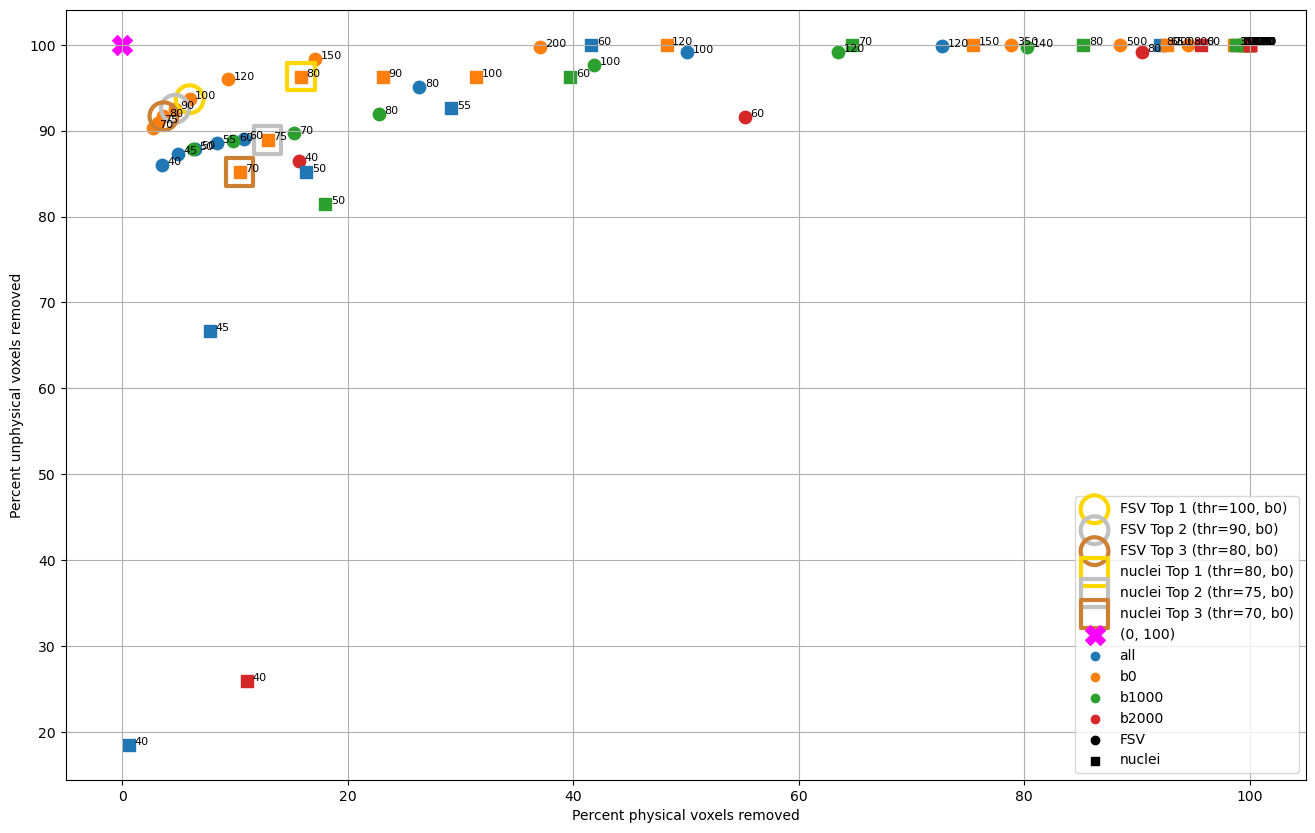

In [168]:
# Plotte prosent ufysiske voxler vs. prosent fysiske voxler

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02-0003/percent_voxels_left_results.csv"
df = pd.read_csv(csv_path)

file_pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

def parse_filename(fname):
    m = file_pattern.match(fname)
    
    return pd.Series([m.group(1), m.group(2), int(m.group(3))])

df[["segmentation", "snr_type", "threshold"]] = df["Filename"].apply(parse_filename)

df = df.dropna(subset=["segmentation", "snr_type", "threshold"]).copy()
df["threshold"] = df["threshold"].astype(int)

colors = {
    "all": "tab:blue",
    "b0": "tab:orange",
    "b1000": "tab:green",
    "b2000": "tab:red",
}

markers = {
    "FSV": "o",
    "nuclei": "s"
}

plt.figure(figsize=(16, 10))

df_plot = df.dropna(subset=["Percent_physical_voxels_removed", "Percent_unphysical_voxels_removed"]).copy()

# Calculates distance to (0,100)
df_plot["dist2"] = (
    (df_plot["Percent_physical_voxels_removed"])**2 + (df_plot["Percent_unphysical_voxels_removed"] - 100)**2
)

#closest_row = df_plot.loc[df_plot["dist2"].idxmin()]

#top3 = df_plot.nsmallest(3, "dist2")
top3_each = (
    df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))
)

for _, row in df_plot.iterrows():
    x = row["Percent_physical_voxels_removed"]
    y = row["Percent_unphysical_voxels_removed"]

    snr = row["snr_type"]
    seg = row["segmentation"]
    thr = row["threshold"]

    plt.scatter(x, y, color=colors[snr], marker=markers[seg], s=80)

    plt.text(x + 0.5, y, str(thr), fontsize=8)

#plt.scatter(
#    closest_row["Percent_physical_voxels_removed"],
#    closest_row["Percent_unphysical_voxels_removed"],
#    s = 300,
#    facecolors = "none",
#    edgecolors = "black",
#    linewidths = 2.5,
#    label = "Closest (0, 100)"
#)

highlight_colors = ["gold", "silver", "#cd7f32"]

for seg_type in ["FSV", "nuclei"]:
    top_seg = top3_each[top3_each["segmentation"] == seg_type].reset_index(drop=True)

    for i, row in top_seg.iterrows():
        x = row["Percent_physical_voxels_removed"]
        y = row["Percent_unphysical_voxels_removed"]
        label = f"{seg_type} Top {i + 1} (thr={row["threshold"]}, {row["snr_type"]})"
        plt.scatter(
            x, y, 
            s = 400, 
            facecolors = "none",
            edgecolors = highlight_colors[i],
            marker=markers[seg_type],
            linewidths = 3,
            label = label
        )

plt.scatter(
    0, 100,
    color = "magenta",
    marker = "X",
    s = 200,
    label = "(0, 100)"
)

for snr, color in colors.items():
    plt.scatter([], [], color=color, marker="o", label=snr)

for seg, marker in markers.items():
    plt.scatter([], [], color="black", marker=marker, label=seg)

plt.xlabel("Percent physical voxels removed")
plt.ylabel("Percent unphysical voxels removed")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_1228067/2039327700.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))


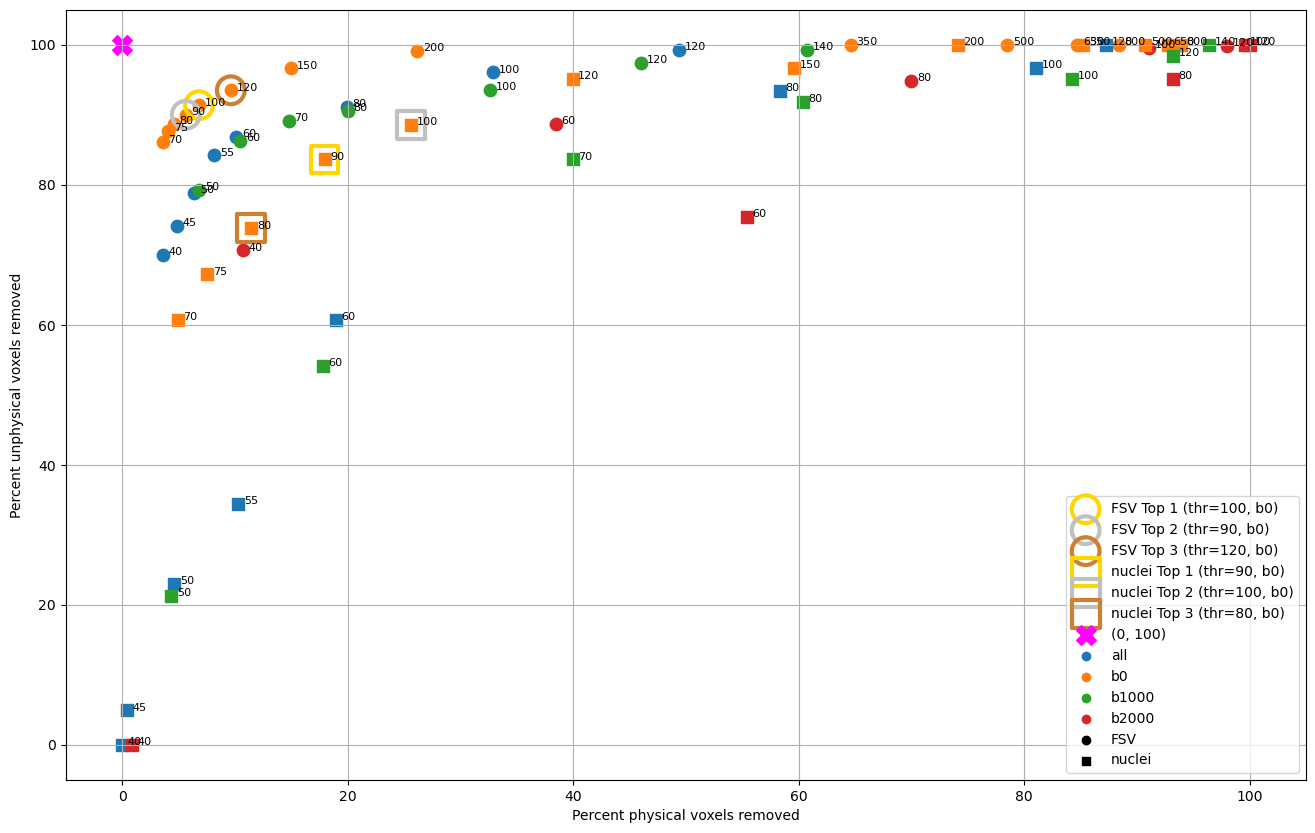

In [169]:
# Plotte prosent ufysiske voxler vs. prosent fysiske voxler

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02-0004/percent_voxels_left_results.csv"
df = pd.read_csv(csv_path)

file_pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

def parse_filename(fname):
    m = file_pattern.match(fname)
    
    return pd.Series([m.group(1), m.group(2), int(m.group(3))])

df[["segmentation", "snr_type", "threshold"]] = df["Filename"].apply(parse_filename)

df = df.dropna(subset=["segmentation", "snr_type", "threshold"]).copy()
df["threshold"] = df["threshold"].astype(int)

colors = {
    "all": "tab:blue",
    "b0": "tab:orange",
    "b1000": "tab:green",
    "b2000": "tab:red",
}

markers = {
    "FSV": "o",
    "nuclei": "s"
}

plt.figure(figsize=(16, 10))

df_plot = df.dropna(subset=["Percent_physical_voxels_removed", "Percent_unphysical_voxels_removed"]).copy()

# Calculates distance to (0,100)
df_plot["dist2"] = (
    (df_plot["Percent_physical_voxels_removed"])**2 + (df_plot["Percent_unphysical_voxels_removed"] - 100)**2
)

#closest_row = df_plot.loc[df_plot["dist2"].idxmin()]

#top3 = df_plot.nsmallest(3, "dist2")
top3_each = (
    df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))
)

for _, row in df_plot.iterrows():
    x = row["Percent_physical_voxels_removed"]
    y = row["Percent_unphysical_voxels_removed"]

    snr = row["snr_type"]
    seg = row["segmentation"]
    thr = row["threshold"]

    plt.scatter(x, y, color=colors[snr], marker=markers[seg], s=80)

    plt.text(x + 0.5, y, str(thr), fontsize=8)

#plt.scatter(
#    closest_row["Percent_physical_voxels_removed"],
#    closest_row["Percent_unphysical_voxels_removed"],
#    s = 300,
#    facecolors = "none",
#    edgecolors = "black",
#    linewidths = 2.5,
#    label = "Closest (0, 100)"
#)

highlight_colors = ["gold", "silver", "#cd7f32"]

for seg_type in ["FSV", "nuclei"]:
    top_seg = top3_each[top3_each["segmentation"] == seg_type].reset_index(drop=True)

    for i, row in top_seg.iterrows():
        x = row["Percent_physical_voxels_removed"]
        y = row["Percent_unphysical_voxels_removed"]
        label = f"{seg_type} Top {i + 1} (thr={row["threshold"]}, {row["snr_type"]})"
        plt.scatter(
            x, y, 
            s = 400, 
            facecolors = "none",
            edgecolors = highlight_colors[i],
            marker=markers[seg_type],
            linewidths = 3,
            label = label
        )

plt.scatter(
    0, 100,
    color = "magenta",
    marker = "X",
    s = 200,
    label = "(0, 100)"
)

for snr, color in colors.items():
    plt.scatter([], [], color=color, marker="o", label=snr)

for seg, marker in markers.items():
    plt.scatter([], [], color="black", marker=marker, label=seg)

plt.xlabel("Percent physical voxels removed")
plt.ylabel("Percent unphysical voxels removed")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_1228067/4233786815.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))


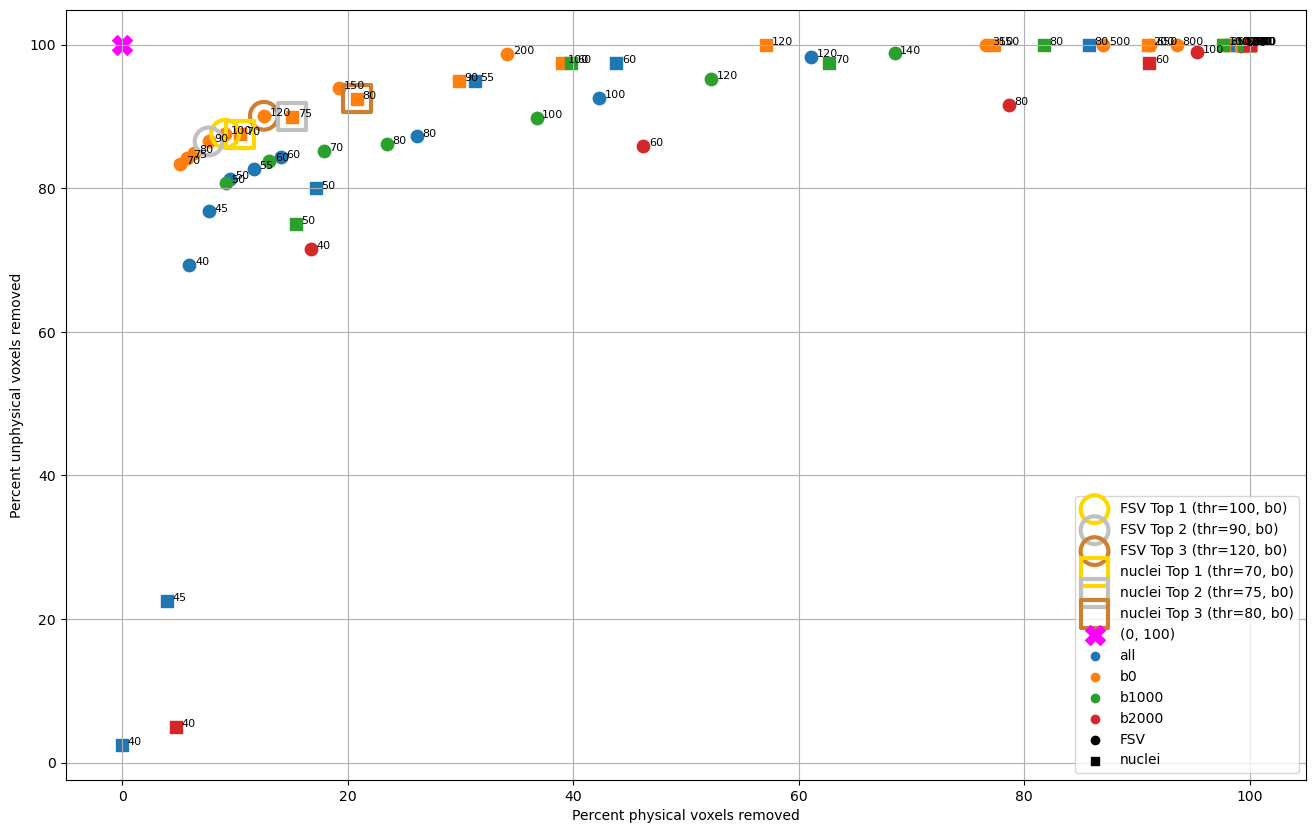

In [170]:
# Plotte prosent ufysiske voxler vs. prosent fysiske voxler

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02-0005/percent_voxels_left_results.csv"
df = pd.read_csv(csv_path)

file_pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

def parse_filename(fname):
    m = file_pattern.match(fname)
    
    return pd.Series([m.group(1), m.group(2), int(m.group(3))])

df[["segmentation", "snr_type", "threshold"]] = df["Filename"].apply(parse_filename)

df = df.dropna(subset=["segmentation", "snr_type", "threshold"]).copy()
df["threshold"] = df["threshold"].astype(int)

colors = {
    "all": "tab:blue",
    "b0": "tab:orange",
    "b1000": "tab:green",
    "b2000": "tab:red",
}

markers = {
    "FSV": "o",
    "nuclei": "s"
}

plt.figure(figsize=(16, 10))

df_plot = df.dropna(subset=["Percent_physical_voxels_removed", "Percent_unphysical_voxels_removed"]).copy()

# Calculates distance to (0,100)
df_plot["dist2"] = (
    (df_plot["Percent_physical_voxels_removed"])**2 + (df_plot["Percent_unphysical_voxels_removed"] - 100)**2
)

#closest_row = df_plot.loc[df_plot["dist2"].idxmin()]

#top3 = df_plot.nsmallest(3, "dist2")
top3_each = (
    df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))
)

for _, row in df_plot.iterrows():
    x = row["Percent_physical_voxels_removed"]
    y = row["Percent_unphysical_voxels_removed"]

    snr = row["snr_type"]
    seg = row["segmentation"]
    thr = row["threshold"]

    plt.scatter(x, y, color=colors[snr], marker=markers[seg], s=80)

    plt.text(x + 0.5, y, str(thr), fontsize=8)

#plt.scatter(
#    closest_row["Percent_physical_voxels_removed"],
#    closest_row["Percent_unphysical_voxels_removed"],
#    s = 300,
#    facecolors = "none",
#    edgecolors = "black",
#    linewidths = 2.5,
#    label = "Closest (0, 100)"
#)

highlight_colors = ["gold", "silver", "#cd7f32"]

for seg_type in ["FSV", "nuclei"]:
    top_seg = top3_each[top3_each["segmentation"] == seg_type].reset_index(drop=True)

    for i, row in top_seg.iterrows():
        x = row["Percent_physical_voxels_removed"]
        y = row["Percent_unphysical_voxels_removed"]
        label = f"{seg_type} Top {i + 1} (thr={row["threshold"]}, {row["snr_type"]})"
        plt.scatter(
            x, y, 
            s = 400, 
            facecolors = "none",
            edgecolors = highlight_colors[i],
            marker=markers[seg_type],
            linewidths = 3,
            label = label
        )

plt.scatter(
    0, 100,
    color = "magenta",
    marker = "X",
    s = 200,
    label = "(0, 100)"
)

for snr, color in colors.items():
    plt.scatter([], [], color=color, marker="o", label=snr)

for seg, marker in markers.items():
    plt.scatter([], [], color="black", marker=marker, label=seg)

plt.xlabel("Percent physical voxels removed")
plt.ylabel("Percent unphysical voxels removed")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_1228067/621209506.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))


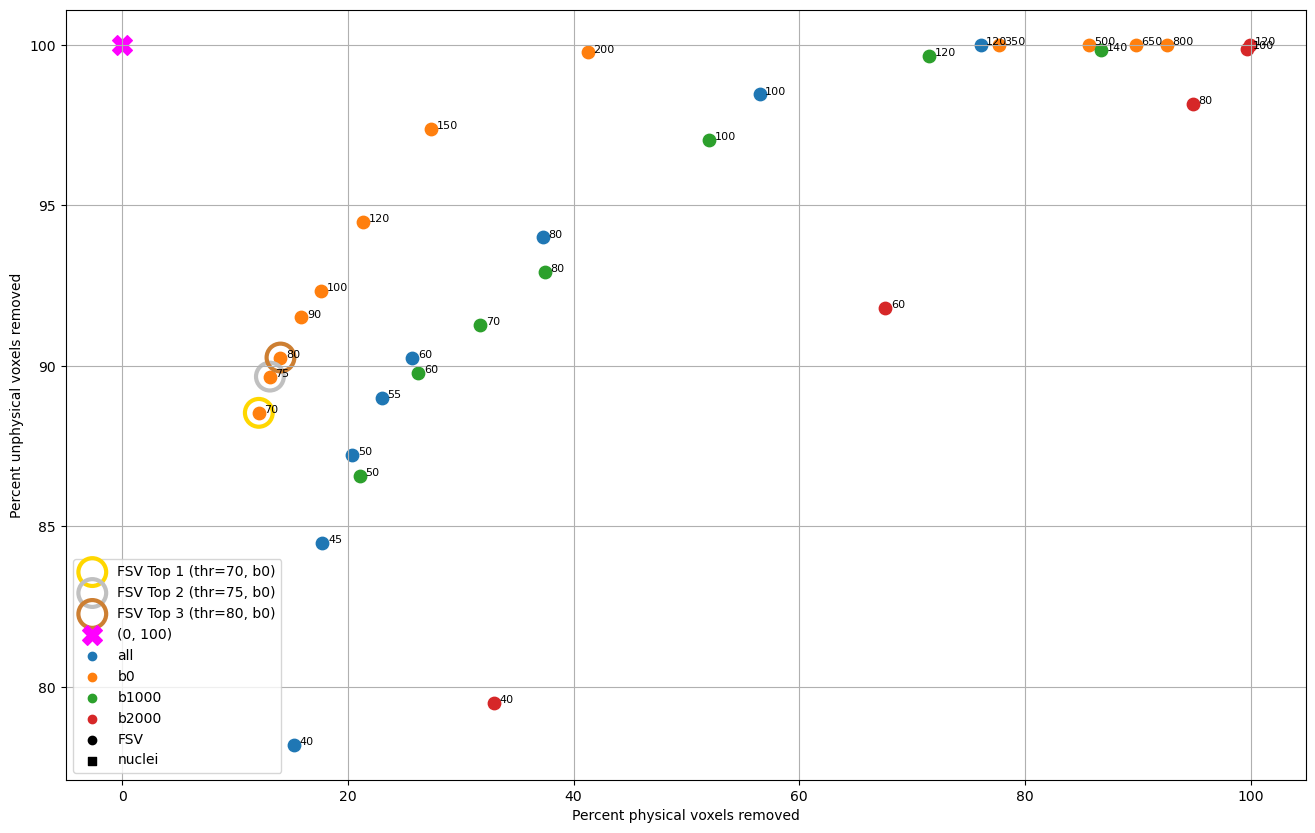

In [171]:
# Plotte prosent ufysiske voxler vs. prosent fysiske voxler

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02-0006/percent_voxels_left_results.csv"
df = pd.read_csv(csv_path)

file_pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

def parse_filename(fname):
    m = file_pattern.match(fname)
    
    return pd.Series([m.group(1), m.group(2), int(m.group(3))])

df[["segmentation", "snr_type", "threshold"]] = df["Filename"].apply(parse_filename)

df = df.dropna(subset=["segmentation", "snr_type", "threshold"]).copy()
df["threshold"] = df["threshold"].astype(int)

colors = {
    "all": "tab:blue",
    "b0": "tab:orange",
    "b1000": "tab:green",
    "b2000": "tab:red",
}

markers = {
    "FSV": "o",
    "nuclei": "s"
}

plt.figure(figsize=(16, 10))

df_plot = df.dropna(subset=["Percent_physical_voxels_removed", "Percent_unphysical_voxels_removed"]).copy()

# Calculates distance to (0,100)
df_plot["dist2"] = (
    (df_plot["Percent_physical_voxels_removed"])**2 + (df_plot["Percent_unphysical_voxels_removed"] - 100)**2
)

#closest_row = df_plot.loc[df_plot["dist2"].idxmin()]

#top3 = df_plot.nsmallest(3, "dist2")
top3_each = (
    df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))
)

for _, row in df_plot.iterrows():
    x = row["Percent_physical_voxels_removed"]
    y = row["Percent_unphysical_voxels_removed"]

    snr = row["snr_type"]
    seg = row["segmentation"]
    thr = row["threshold"]

    plt.scatter(x, y, color=colors[snr], marker=markers[seg], s=80)

    plt.text(x + 0.5, y, str(thr), fontsize=8)

#plt.scatter(
#    closest_row["Percent_physical_voxels_removed"],
#    closest_row["Percent_unphysical_voxels_removed"],
#    s = 300,
#    facecolors = "none",
#    edgecolors = "black",
#    linewidths = 2.5,
#    label = "Closest (0, 100)"
#)

highlight_colors = ["gold", "silver", "#cd7f32"]

for seg_type in ["FSV", "nuclei"]:
    top_seg = top3_each[top3_each["segmentation"] == seg_type].reset_index(drop=True)

    for i, row in top_seg.iterrows():
        x = row["Percent_physical_voxels_removed"]
        y = row["Percent_unphysical_voxels_removed"]
        label = f"{seg_type} Top {i + 1} (thr={row["threshold"]}, {row["snr_type"]})"
        plt.scatter(
            x, y, 
            s = 400, 
            facecolors = "none",
            edgecolors = highlight_colors[i],
            marker=markers[seg_type],
            linewidths = 3,
            label = label
        )

plt.scatter(
    0, 100,
    color = "magenta",
    marker = "X",
    s = 200,
    label = "(0, 100)"
)

for snr, color in colors.items():
    plt.scatter([], [], color=color, marker="o", label=snr)

for seg, marker in markers.items():
    plt.scatter([], [], color="black", marker=marker, label=seg)

plt.xlabel("Percent physical voxels removed")
plt.ylabel("Percent unphysical voxels removed")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_1228067/3864865892.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))


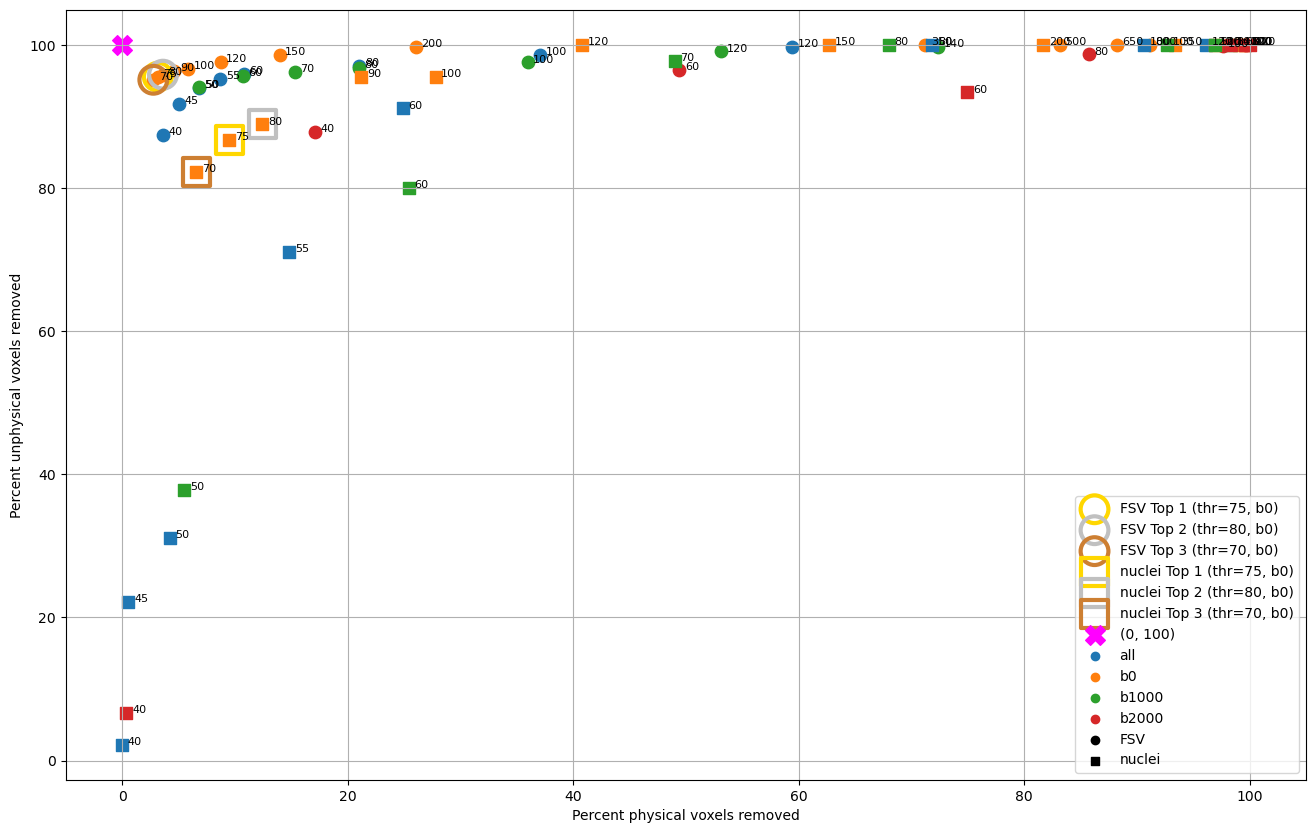

In [172]:
# Plotte prosent ufysiske voxler vs. prosent fysiske voxler

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02-0007/percent_voxels_left_results.csv"
df = pd.read_csv(csv_path)

file_pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

def parse_filename(fname):
    m = file_pattern.match(fname)
    
    return pd.Series([m.group(1), m.group(2), int(m.group(3))])

df[["segmentation", "snr_type", "threshold"]] = df["Filename"].apply(parse_filename)

df = df.dropna(subset=["segmentation", "snr_type", "threshold"]).copy()
df["threshold"] = df["threshold"].astype(int)

colors = {
    "all": "tab:blue",
    "b0": "tab:orange",
    "b1000": "tab:green",
    "b2000": "tab:red",
}

markers = {
    "FSV": "o",
    "nuclei": "s"
}

plt.figure(figsize=(16, 10))

df_plot = df.dropna(subset=["Percent_physical_voxels_removed", "Percent_unphysical_voxels_removed"]).copy()

# Calculates distance to (0,100)
df_plot["dist2"] = (
    (df_plot["Percent_physical_voxels_removed"])**2 + (df_plot["Percent_unphysical_voxels_removed"] - 100)**2
)

#closest_row = df_plot.loc[df_plot["dist2"].idxmin()]

#top3 = df_plot.nsmallest(3, "dist2")
top3_each = (
    df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))
)

for _, row in df_plot.iterrows():
    x = row["Percent_physical_voxels_removed"]
    y = row["Percent_unphysical_voxels_removed"]

    snr = row["snr_type"]
    seg = row["segmentation"]
    thr = row["threshold"]

    plt.scatter(x, y, color=colors[snr], marker=markers[seg], s=80)

    plt.text(x + 0.5, y, str(thr), fontsize=8)

#plt.scatter(
#    closest_row["Percent_physical_voxels_removed"],
#    closest_row["Percent_unphysical_voxels_removed"],
#    s = 300,
#    facecolors = "none",
#    edgecolors = "black",
#    linewidths = 2.5,
#    label = "Closest (0, 100)"
#)

highlight_colors = ["gold", "silver", "#cd7f32"]

for seg_type in ["FSV", "nuclei"]:
    top_seg = top3_each[top3_each["segmentation"] == seg_type].reset_index(drop=True)

    for i, row in top_seg.iterrows():
        x = row["Percent_physical_voxels_removed"]
        y = row["Percent_unphysical_voxels_removed"]
        label = f"{seg_type} Top {i + 1} (thr={row["threshold"]}, {row["snr_type"]})"
        plt.scatter(
            x, y, 
            s = 400, 
            facecolors = "none",
            edgecolors = highlight_colors[i],
            marker=markers[seg_type],
            linewidths = 3,
            label = label
        )

plt.scatter(
    0, 100,
    color = "magenta",
    marker = "X",
    s = 200,
    label = "(0, 100)"
)

for snr, color in colors.items():
    plt.scatter([], [], color=color, marker="o", label=snr)

for seg, marker in markers.items():
    plt.scatter([], [], color="black", marker=marker, label=seg)

plt.xlabel("Percent physical voxels removed")
plt.ylabel("Percent unphysical voxels removed")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_1228067/3013020695.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))


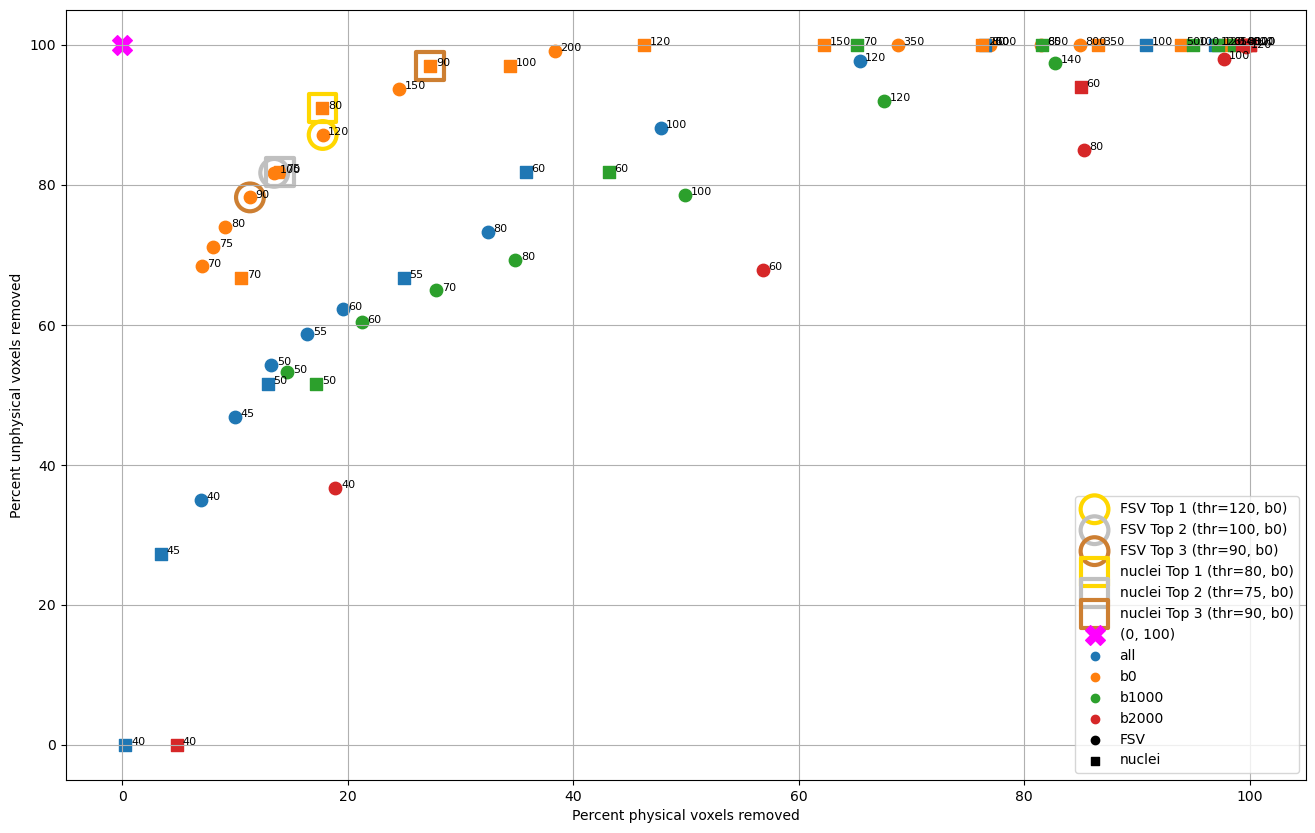

In [173]:
# Plotte prosent ufysiske voxler vs. prosent fysiske voxler

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02-0009/percent_voxels_left_results.csv"
df = pd.read_csv(csv_path)

file_pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

def parse_filename(fname):
    m = file_pattern.match(fname)
    
    return pd.Series([m.group(1), m.group(2), int(m.group(3))])

df[["segmentation", "snr_type", "threshold"]] = df["Filename"].apply(parse_filename)

df = df.dropna(subset=["segmentation", "snr_type", "threshold"]).copy()
df["threshold"] = df["threshold"].astype(int)

colors = {
    "all": "tab:blue",
    "b0": "tab:orange",
    "b1000": "tab:green",
    "b2000": "tab:red",
}

markers = {
    "FSV": "o",
    "nuclei": "s"
}

plt.figure(figsize=(16, 10))

df_plot = df.dropna(subset=["Percent_physical_voxels_removed", "Percent_unphysical_voxels_removed"]).copy()

# Calculates distance to (0,100)
df_plot["dist2"] = (
    (df_plot["Percent_physical_voxels_removed"])**2 + (df_plot["Percent_unphysical_voxels_removed"] - 100)**2
)

#closest_row = df_plot.loc[df_plot["dist2"].idxmin()]

#top3 = df_plot.nsmallest(3, "dist2")
top3_each = (
    df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))
)

for _, row in df_plot.iterrows():
    x = row["Percent_physical_voxels_removed"]
    y = row["Percent_unphysical_voxels_removed"]

    snr = row["snr_type"]
    seg = row["segmentation"]
    thr = row["threshold"]

    plt.scatter(x, y, color=colors[snr], marker=markers[seg], s=80)

    plt.text(x + 0.5, y, str(thr), fontsize=8)

#plt.scatter(
#    closest_row["Percent_physical_voxels_removed"],
#    closest_row["Percent_unphysical_voxels_removed"],
#    s = 300,
#    facecolors = "none",
#    edgecolors = "black",
#    linewidths = 2.5,
#    label = "Closest (0, 100)"
#)

highlight_colors = ["gold", "silver", "#cd7f32"]

for seg_type in ["FSV", "nuclei"]:
    top_seg = top3_each[top3_each["segmentation"] == seg_type].reset_index(drop=True)

    for i, row in top_seg.iterrows():
        x = row["Percent_physical_voxels_removed"]
        y = row["Percent_unphysical_voxels_removed"]
        label = f"{seg_type} Top {i + 1} (thr={row["threshold"]}, {row["snr_type"]})"
        plt.scatter(
            x, y, 
            s = 400, 
            facecolors = "none",
            edgecolors = highlight_colors[i],
            marker=markers[seg_type],
            linewidths = 3,
            label = label
        )

plt.scatter(
    0, 100,
    color = "magenta",
    marker = "X",
    s = 200,
    label = "(0, 100)"
)

for snr, color in colors.items():
    plt.scatter([], [], color=color, marker="o", label=snr)

for seg, marker in markers.items():
    plt.scatter([], [], color="black", marker=marker, label=seg)

plt.xlabel("Percent physical voxels removed")
plt.ylabel("Percent unphysical voxels removed")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_1228067/3205083075.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))


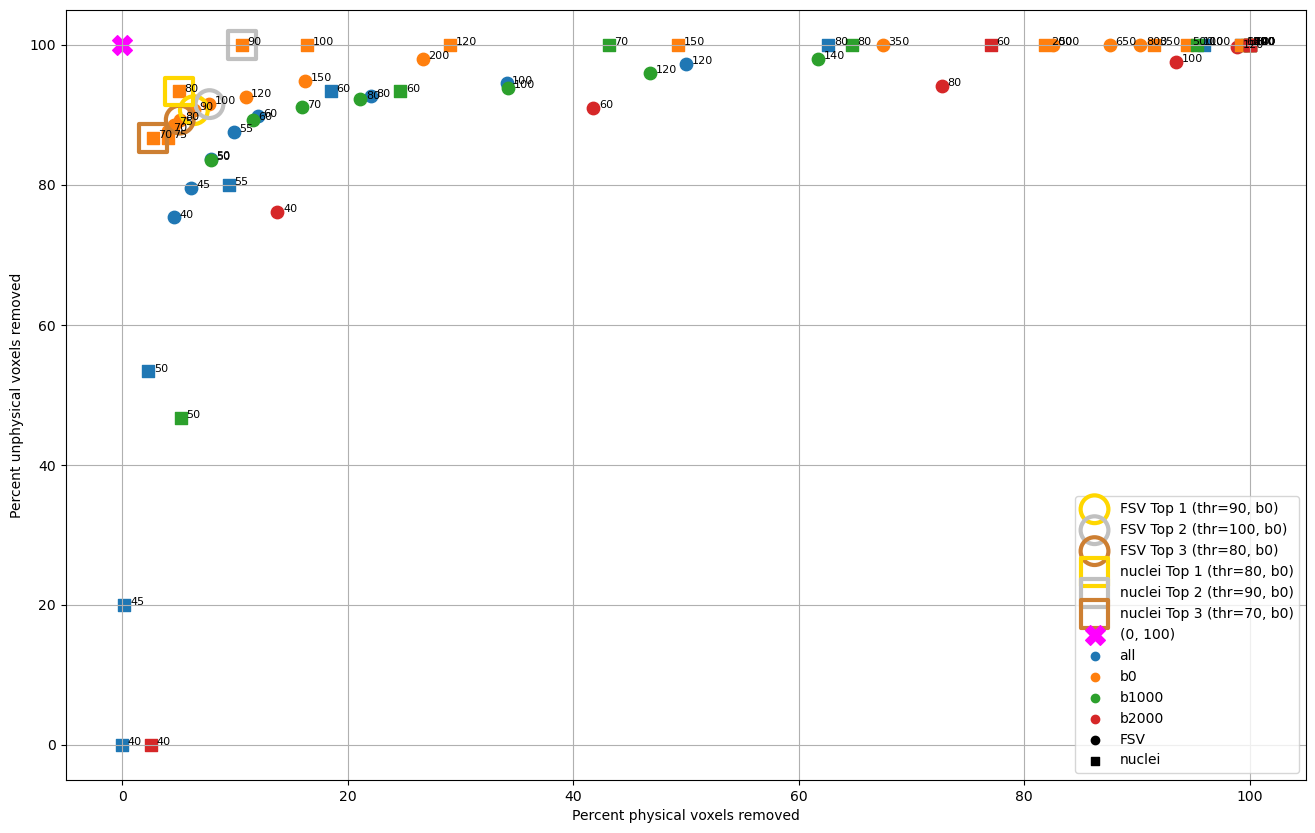

In [174]:
# Plotte prosent ufysiske voxler vs. prosent fysiske voxler

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02-0011/percent_voxels_left_results.csv"
df = pd.read_csv(csv_path)

file_pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

def parse_filename(fname):
    m = file_pattern.match(fname)
    
    return pd.Series([m.group(1), m.group(2), int(m.group(3))])

df[["segmentation", "snr_type", "threshold"]] = df["Filename"].apply(parse_filename)

df = df.dropna(subset=["segmentation", "snr_type", "threshold"]).copy()
df["threshold"] = df["threshold"].astype(int)

colors = {
    "all": "tab:blue",
    "b0": "tab:orange",
    "b1000": "tab:green",
    "b2000": "tab:red",
}

markers = {
    "FSV": "o",
    "nuclei": "s"
}

plt.figure(figsize=(16, 10))

df_plot = df.dropna(subset=["Percent_physical_voxels_removed", "Percent_unphysical_voxels_removed"]).copy()

# Calculates distance to (0,100)
df_plot["dist2"] = (
    (df_plot["Percent_physical_voxels_removed"])**2 + (df_plot["Percent_unphysical_voxels_removed"] - 100)**2
)

#closest_row = df_plot.loc[df_plot["dist2"].idxmin()]

#top3 = df_plot.nsmallest(3, "dist2")
top3_each = (
    df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))
)

for _, row in df_plot.iterrows():
    x = row["Percent_physical_voxels_removed"]
    y = row["Percent_unphysical_voxels_removed"]

    snr = row["snr_type"]
    seg = row["segmentation"]
    thr = row["threshold"]

    plt.scatter(x, y, color=colors[snr], marker=markers[seg], s=80)

    plt.text(x + 0.5, y, str(thr), fontsize=8)

#plt.scatter(
#    closest_row["Percent_physical_voxels_removed"],
#    closest_row["Percent_unphysical_voxels_removed"],
#    s = 300,
#    facecolors = "none",
#    edgecolors = "black",
#    linewidths = 2.5,
#    label = "Closest (0, 100)"
#)

highlight_colors = ["gold", "silver", "#cd7f32"]

for seg_type in ["FSV", "nuclei"]:
    top_seg = top3_each[top3_each["segmentation"] == seg_type].reset_index(drop=True)

    for i, row in top_seg.iterrows():
        x = row["Percent_physical_voxels_removed"]
        y = row["Percent_unphysical_voxels_removed"]
        label = f"{seg_type} Top {i + 1} (thr={row["threshold"]}, {row["snr_type"]})"
        plt.scatter(
            x, y, 
            s = 400, 
            facecolors = "none",
            edgecolors = highlight_colors[i],
            marker=markers[seg_type],
            linewidths = 3,
            label = label
        )

plt.scatter(
    0, 100,
    color = "magenta",
    marker = "X",
    s = 200,
    label = "(0, 100)"
)

for snr, color in colors.items():
    plt.scatter([], [], color=color, marker="o", label=snr)

for seg, marker in markers.items():
    plt.scatter([], [], color="black", marker=marker, label=seg)

plt.xlabel("Percent physical voxels removed")
plt.ylabel("Percent unphysical voxels removed")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_1228067/697424487.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))


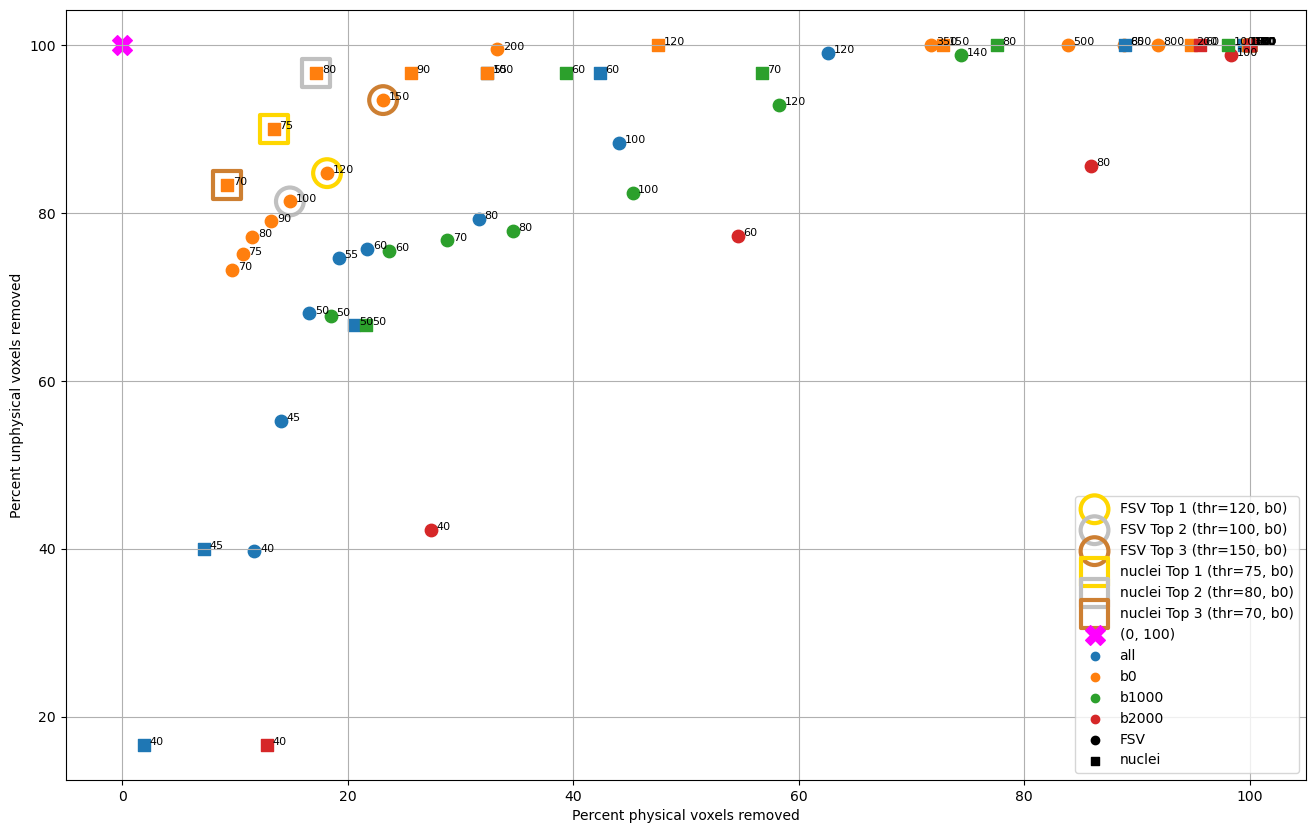

In [175]:
# Plotte prosent ufysiske voxler vs. prosent fysiske voxler

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02-0013/percent_voxels_left_results.csv"
df = pd.read_csv(csv_path)

file_pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

def parse_filename(fname):
    m = file_pattern.match(fname)
    
    return pd.Series([m.group(1), m.group(2), int(m.group(3))])

df[["segmentation", "snr_type", "threshold"]] = df["Filename"].apply(parse_filename)

df = df.dropna(subset=["segmentation", "snr_type", "threshold"]).copy()
df["threshold"] = df["threshold"].astype(int)

colors = {
    "all": "tab:blue",
    "b0": "tab:orange",
    "b1000": "tab:green",
    "b2000": "tab:red",
}

markers = {
    "FSV": "o",
    "nuclei": "s"
}

plt.figure(figsize=(16, 10))

df_plot = df.dropna(subset=["Percent_physical_voxels_removed", "Percent_unphysical_voxels_removed"]).copy()

# Calculates distance to (0,100)
df_plot["dist2"] = (
    (df_plot["Percent_physical_voxels_removed"])**2 + (df_plot["Percent_unphysical_voxels_removed"] - 100)**2
)

#closest_row = df_plot.loc[df_plot["dist2"].idxmin()]

#top3 = df_plot.nsmallest(3, "dist2")
top3_each = (
    df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))
)

for _, row in df_plot.iterrows():
    x = row["Percent_physical_voxels_removed"]
    y = row["Percent_unphysical_voxels_removed"]

    snr = row["snr_type"]
    seg = row["segmentation"]
    thr = row["threshold"]

    plt.scatter(x, y, color=colors[snr], marker=markers[seg], s=80)

    plt.text(x + 0.5, y, str(thr), fontsize=8)

#plt.scatter(
#    closest_row["Percent_physical_voxels_removed"],
#    closest_row["Percent_unphysical_voxels_removed"],
#    s = 300,
#    facecolors = "none",
#    edgecolors = "black",
#    linewidths = 2.5,
#    label = "Closest (0, 100)"
#)

highlight_colors = ["gold", "silver", "#cd7f32"]

for seg_type in ["FSV", "nuclei"]:
    top_seg = top3_each[top3_each["segmentation"] == seg_type].reset_index(drop=True)

    for i, row in top_seg.iterrows():
        x = row["Percent_physical_voxels_removed"]
        y = row["Percent_unphysical_voxels_removed"]
        label = f"{seg_type} Top {i + 1} (thr={row["threshold"]}, {row["snr_type"]})"
        plt.scatter(
            x, y, 
            s = 400, 
            facecolors = "none",
            edgecolors = highlight_colors[i],
            marker=markers[seg_type],
            linewidths = 3,
            label = label
        )

plt.scatter(
    0, 100,
    color = "magenta",
    marker = "X",
    s = 200,
    label = "(0, 100)"
)

for snr, color in colors.items():
    plt.scatter([], [], color=color, marker="o", label=snr)

for seg, marker in markers.items():
    plt.scatter([], [], color="black", marker=marker, label=seg)

plt.xlabel("Percent physical voxels removed")
plt.ylabel("Percent unphysical voxels removed")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_1228067/2527738470.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))


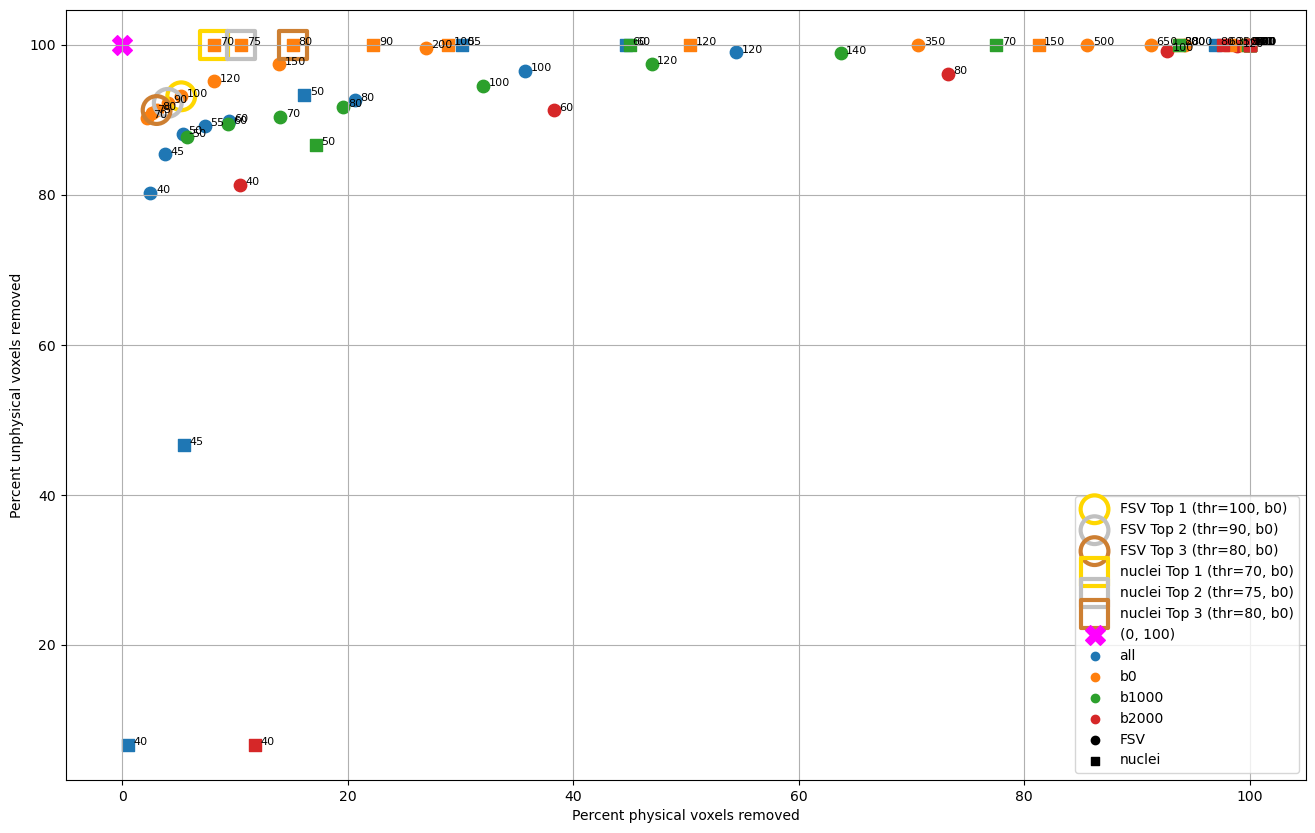

In [176]:
# Plotte prosent ufysiske voxler vs. prosent fysiske voxler

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02-0014/percent_voxels_left_results.csv"
df = pd.read_csv(csv_path)

file_pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

def parse_filename(fname):
    m = file_pattern.match(fname)
    
    return pd.Series([m.group(1), m.group(2), int(m.group(3))])

df[["segmentation", "snr_type", "threshold"]] = df["Filename"].apply(parse_filename)

df = df.dropna(subset=["segmentation", "snr_type", "threshold"]).copy()
df["threshold"] = df["threshold"].astype(int)

colors = {
    "all": "tab:blue",
    "b0": "tab:orange",
    "b1000": "tab:green",
    "b2000": "tab:red",
}

markers = {
    "FSV": "o",
    "nuclei": "s"
}

plt.figure(figsize=(16, 10))

df_plot = df.dropna(subset=["Percent_physical_voxels_removed", "Percent_unphysical_voxels_removed"]).copy()

# Calculates distance to (0,100)
df_plot["dist2"] = (
    (df_plot["Percent_physical_voxels_removed"])**2 + (df_plot["Percent_unphysical_voxels_removed"] - 100)**2
)

#closest_row = df_plot.loc[df_plot["dist2"].idxmin()]

#top3 = df_plot.nsmallest(3, "dist2")
top3_each = (
    df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))
)

for _, row in df_plot.iterrows():
    x = row["Percent_physical_voxels_removed"]
    y = row["Percent_unphysical_voxels_removed"]

    snr = row["snr_type"]
    seg = row["segmentation"]
    thr = row["threshold"]

    plt.scatter(x, y, color=colors[snr], marker=markers[seg], s=80)

    plt.text(x + 0.5, y, str(thr), fontsize=8)

#plt.scatter(
#    closest_row["Percent_physical_voxels_removed"],
#    closest_row["Percent_unphysical_voxels_removed"],
#    s = 300,
#    facecolors = "none",
#    edgecolors = "black",
#    linewidths = 2.5,
#    label = "Closest (0, 100)"
#)

highlight_colors = ["gold", "silver", "#cd7f32"]

for seg_type in ["FSV", "nuclei"]:
    top_seg = top3_each[top3_each["segmentation"] == seg_type].reset_index(drop=True)

    for i, row in top_seg.iterrows():
        x = row["Percent_physical_voxels_removed"]
        y = row["Percent_unphysical_voxels_removed"]
        label = f"{seg_type} Top {i + 1} (thr={row["threshold"]}, {row["snr_type"]})"
        plt.scatter(
            x, y, 
            s = 400, 
            facecolors = "none",
            edgecolors = highlight_colors[i],
            marker=markers[seg_type],
            linewidths = 3,
            label = label
        )

plt.scatter(
    0, 100,
    color = "magenta",
    marker = "X",
    s = 200,
    label = "(0, 100)"
)

for snr, color in colors.items():
    plt.scatter([], [], color=color, marker="o", label=snr)

for seg, marker in markers.items():
    plt.scatter([], [], color="black", marker=marker, label=seg)

plt.xlabel("Percent physical voxels removed")
plt.ylabel("Percent unphysical voxels removed")
plt.grid(True)
plt.legend()
plt.show()

/tmp/ipykernel_1228067/2237579803.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))


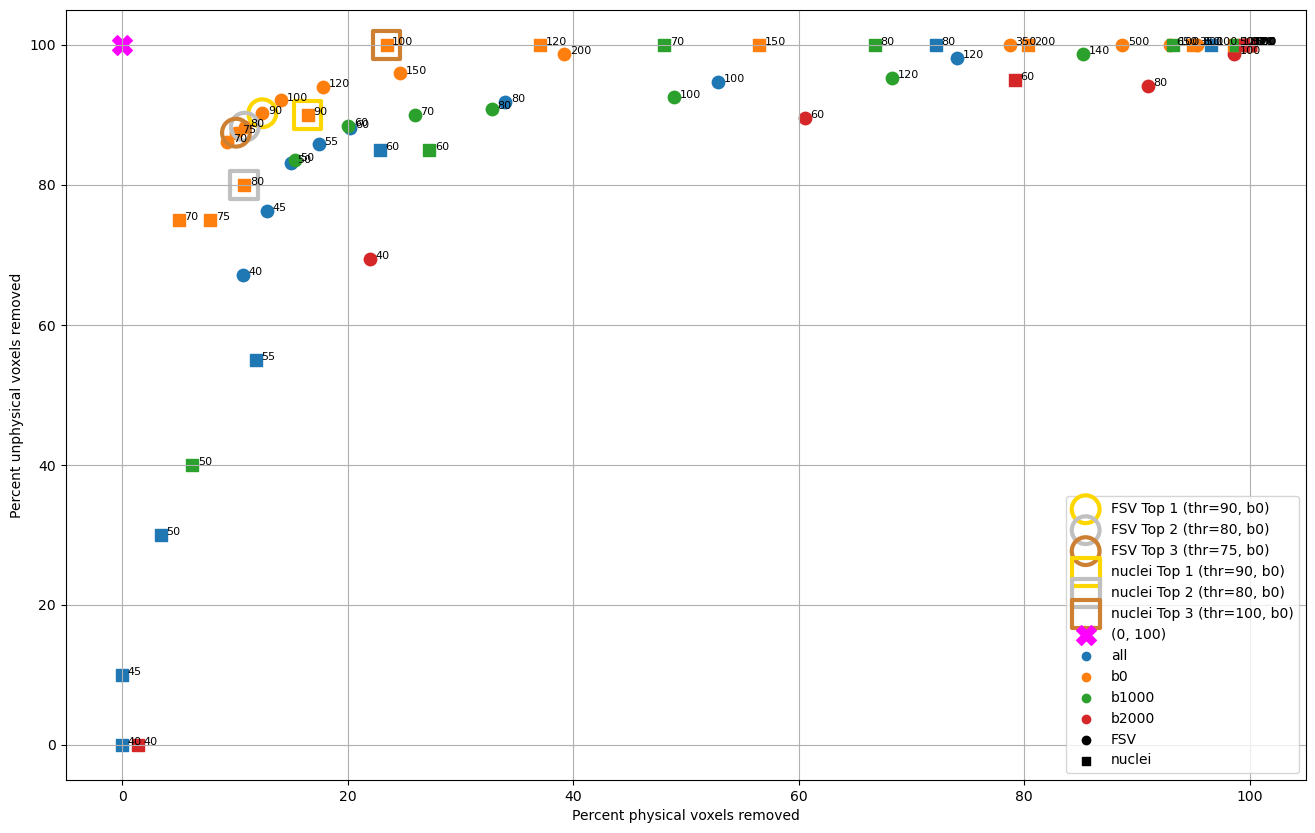

In [177]:
# Plotte prosent ufysiske voxler vs. prosent fysiske voxler

csv_path = "/home/thientn/MASTEROPPGAVE/IMPARK/02-0015/percent_voxels_left_results.csv"
df = pd.read_csv(csv_path)

file_pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

def parse_filename(fname):
    m = file_pattern.match(fname)
    
    return pd.Series([m.group(1), m.group(2), int(m.group(3))])

df[["segmentation", "snr_type", "threshold"]] = df["Filename"].apply(parse_filename)

df = df.dropna(subset=["segmentation", "snr_type", "threshold"]).copy()
df["threshold"] = df["threshold"].astype(int)

colors = {
    "all": "tab:blue",
    "b0": "tab:orange",
    "b1000": "tab:green",
    "b2000": "tab:red",
}

markers = {
    "FSV": "o",
    "nuclei": "s"
}

plt.figure(figsize=(16, 10))

df_plot = df.dropna(subset=["Percent_physical_voxels_removed", "Percent_unphysical_voxels_removed"]).copy()

# Calculates distance to (0,100)
df_plot["dist2"] = (
    (df_plot["Percent_physical_voxels_removed"])**2 + (df_plot["Percent_unphysical_voxels_removed"] - 100)**2
)

#closest_row = df_plot.loc[df_plot["dist2"].idxmin()]

#top3 = df_plot.nsmallest(3, "dist2")
top3_each = (
    df_plot.groupby("segmentation", group_keys=False).apply(lambda g: g.nsmallest(3, "dist2"))
)

for _, row in df_plot.iterrows():
    x = row["Percent_physical_voxels_removed"]
    y = row["Percent_unphysical_voxels_removed"]

    snr = row["snr_type"]
    seg = row["segmentation"]
    thr = row["threshold"]

    plt.scatter(x, y, color=colors[snr], marker=markers[seg], s=80)

    plt.text(x + 0.5, y, str(thr), fontsize=8)

#plt.scatter(
#    closest_row["Percent_physical_voxels_removed"],
#    closest_row["Percent_unphysical_voxels_removed"],
#    s = 300,
#    facecolors = "none",
#    edgecolors = "black",
#    linewidths = 2.5,
#    label = "Closest (0, 100)"
#)

highlight_colors = ["gold", "silver", "#cd7f32"]

for seg_type in ["FSV", "nuclei"]:
    top_seg = top3_each[top3_each["segmentation"] == seg_type].reset_index(drop=True)

    for i, row in top_seg.iterrows():
        x = row["Percent_physical_voxels_removed"]
        y = row["Percent_unphysical_voxels_removed"]
        label = f"{seg_type} Top {i + 1} (thr={row["threshold"]}, {row["snr_type"]})"
        plt.scatter(
            x, y, 
            s = 400, 
            facecolors = "none",
            edgecolors = highlight_colors[i],
            marker=markers[seg_type],
            linewidths = 3,
            label = label
        )

plt.scatter(
    0, 100,
    color = "magenta",
    marker = "X",
    s = 200,
    label = "(0, 100)"
)

for snr, color in colors.items():
    plt.scatter([], [], color=color, marker="o", label=snr)

for seg, marker in markers.items():
    plt.scatter([], [], color="black", marker=marker, label=seg)

plt.xlabel("Percent physical voxels removed")
plt.ylabel("Percent unphysical voxels removed")
plt.grid(True)
plt.legend()
plt.show()

In [253]:
# Finne optimal maske å bruke i videre analyse

base_dir = Path("/home/thientn/MASTEROPPGAVE/IMPARK")
csv_paths = sorted(base_dir.rglob("percent_voxels_left_results.csv"))

print(f"Fant {len(csv_paths)} CSV-filer")

pattern = re.compile(r"seg_(nuclei|FSV)_union_SNR_mask_(b0|b1000|b2000|all)_thr(\d+)\.nii\.gz")

all_rows = []

for csv_path in csv_paths:
    df = pd.read_csv(csv_path)

    parsed = df["Filename"].str.extract(pattern)
    parsed.columns = ["segmentation", "snr_type", "threshold"]
    df = pd.concat([df, parsed], axis = 1)

    df = df.dropna(subset=[
        "segmentation",
        "snr_type",
        "threshold",
        "Percent_physical_voxels_removed",
        "Percent_unphysical_voxels_removed"
    ]).copy()

    df["threshold"] = df["threshold"].astype(int)

    df["candidate"] = (
        df["segmentation"] + "_" +
        df["snr_type"] + "_thr" + 
        df["threshold"].astype(str)
    )

    df["subject"] = csv_path.parent.name

    df["dist2"] = (
        df["Percent_physical_voxels_removed"]**2 + (df["Percent_unphysical_voxels_removed"] - 100)**2
    )

    all_rows.append(df[["subject", "segmentation", "candidate", "dist2"]])

all_data = pd.concat(all_rows, ignore_index=True)

summary = (
    all_data.groupby(["segmentation", "candidate"])["dist2"].agg(["median", "mean", "std", "count"]).reset_index()
)

summary_fsv = (
    summary[summary["segmentation"] == "FSV"].sort_values(["median", "count", "mean"], ascending=[True, False, True]).reset_index(drop=True)
)

summary_nuclei = (
    summary[summary["segmentation"] == "nuclei"].sort_values(["median", "count", "mean"], ascending=[True, False, True]).reset_index(drop=True)
)

best_fsv = summary_fsv.iloc[0]
best_nuclei = summary_nuclei.iloc[0]

print(f"Beste FSV-maske: {best_fsv}")
print(f"Beste nuclei-maske: {best_nuclei}")
print(f"Top 10 FSV-masker: {summary_fsv.head(5)}")
print(f"Top 10 nuclei-masker: {summary_nuclei.head(5)}")

Fant 33 CSV-filer
Beste FSV-maske: segmentation              FSV
candidate       FSV_b0_thr100
median             131.870327
mean               209.326554
std                180.405595
count                      33
Name: 0, dtype: object
Beste nuclei-maske: segmentation             nuclei
candidate       nuclei_b0_thr80
median               577.658216
mean                 738.011146
std                  587.311218
count                        32
Name: 0, dtype: object
Top 10 FSV-masker:   segmentation      candidate      median        mean         std  count
0          FSV  FSV_b0_thr100  131.870327  209.326554  180.405595     33
1          FSV   FSV_b0_thr90  131.909367  202.919741  178.095133     33
2          FSV   FSV_b0_thr80  148.235164  212.082950  192.916949     33
3          FSV   FSV_b0_thr75  169.126429  226.528993  212.615238     33
4          FSV   FSV_b0_thr70  183.674024  249.462154  239.881670     33
Top 10 nuclei-masker:   segmentation         candidate       median   